In [ ]:
import zipfile

with zipfile.ZipFile('/content/archive.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("Dataset berhasil diextract")

Dataset berhasil diextract


In [ ]:
import os
os.listdir('/content/dataset')

['Covid19-dataset']

In [ ]:
import tensorflow as tf

train_dir = '/content/dataset/Covid19-dataset/train'
test_dir = '/content/dataset/Covid19-dataset/test'

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(224,224),
    batch_size=32
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(224,224),
    batch_size=32
)

Found 251 files belonging to 3 classes.
Found 66 files belonging to 3 classes.


In [ ]:
from tensorflow.keras import layers, Sequential

model = Sequential([

    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dense(3)
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=5
)

Epoch 1/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 41s 5s/step - accuracy: 0.4303 - loss: 3.2287 - val_accuracy: 0.6818 - val_loss: 0.8574
Epoch 2/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 33s 4s/step - accuracy: 0.7649 - loss: 0.7457 - val_accuracy: 0.7576 - val_loss: 0.6442
Epoch 3/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 30s 4s/step - accuracy: 0.9203 - loss: 0.2597 - val_accuracy: 0.7273 - val_loss: 0.4696
Epoch 4/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 30s 4s/step - accuracy: 0.9442 - loss: 0.1361 - val_accuracy: 0.8939 - val_loss: 0.2885
Epoch 5/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 40s 4s/step - accuracy: 0.9801 - loss: 0.0647 - val_accuracy: 0.8485 - val_loss: 0.3657


In [ ]:
model.save('my_image_classifier_model.h5')

In [ ]:
import os
os.listdir('/content')

['.config',
 'my_image_classifier_model.h5',
 'drive',
 'dataset',
 'archive.zip',
 'sample_data']

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
model.save('/content/drive/MyDrive/my_image_classifier_model.h5')

In [ ]:
loaded_model = tf.keras.models.load_model('/content/drive/MyDrive/my_image_classifier_model.h5')
loaded_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,907,781 (91.20 MB)

 Trainable params: 23,907,779 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [ ]:
from tensorflow.keras.models import load_model

model = load_model('/content/my_image_classifier_model.h5')

print("Model berhasil diload")

Model berhasil diload


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array

# path gambar test
img_path = '/content/0104.jpeg'

# load gambar
img = load_img(img_path, target_size=(224,224))

# ubah ke array
img_array = img_to_array(img)

# tambah dimensi
img_array = np.expand_dims(img_array, axis=0)

# prediksi
prediction = loaded_model.predict(img_array)

# nama class
class_names = ['Covid', 'Normal', 'Viral Pneumonia']

# ambil hasil terbesar
score = np.argmax(prediction)

# tampilkan gambar
plt.imshow(img)
plt.axis('off')

# tampilkan hasil
print("Prediksi:", class_names[score])

FileNotFoundError: [Errno 2] No such file or directory: '/content/0104.jpeg'

In [ ]:
import os
os.listdir('/content')

['.config',
 'my_image_classifier_model.h5',
 'drive',
 'dataset',
 'archive.zip',
 'sample_data']

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
Prediksi: Covid


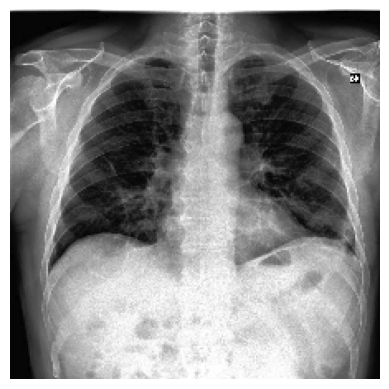

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array

# Updated image path to an existing image in the dataset
img_path = '/content/dataset/Covid19-dataset/test/Covid/0100.jpeg'

img = load_img(img_path, target_size=(224,224))

img_array = img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

prediction = loaded_model.predict(img_array)

class_names = ['Covid', 'Normal', 'Viral Pneumonia']

score = np.argmax(prediction)

plt.imshow(img)
plt.axis('off')

print("Prediksi:", class_names[score])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step
Prediksi: Viral Pneumonia


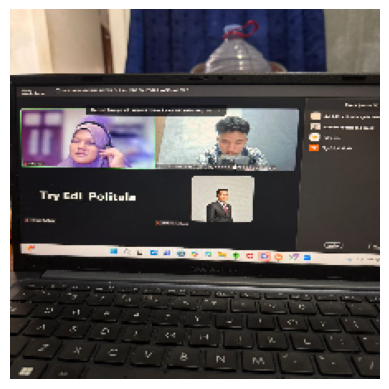

In [26]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array

img_path = "/content/drive/MyDrive/ZOOMMMM.jpeg"

img = load_img(img_path, target_size=(224,224))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

pred = loaded_model.predict(img_array)

class_names = ['Covid', 'Normal', 'Viral Pneumonia']

print("Prediksi:", class_names[np.argmax(pred)])

plt.imshow(img)
plt.axis("off")
plt.show()